Generating noisy 4D dataset...


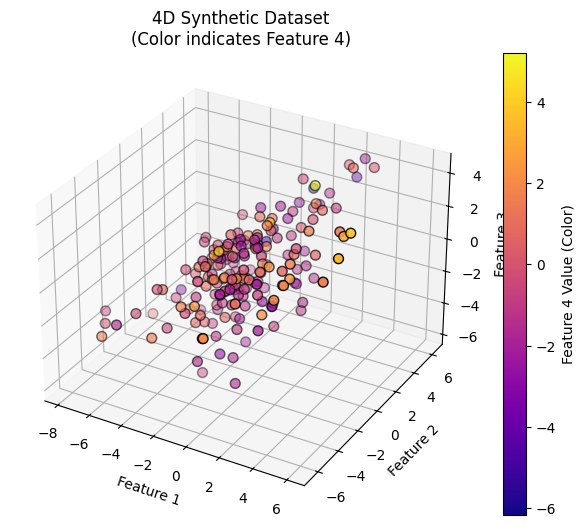


--- Training Linear (3 CNOTs) ---
Accuracy: 53.33% | Time: 37.15 seconds

--- Training Circular (4 CNOTs) ---
Accuracy: 55.00% | Time: 44.27 seconds

--- Training Full (6 CNOTs) ---
Accuracy: 56.67% | Time: 58.05 seconds

Computing boundary grids... (This will take a few minutes)


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


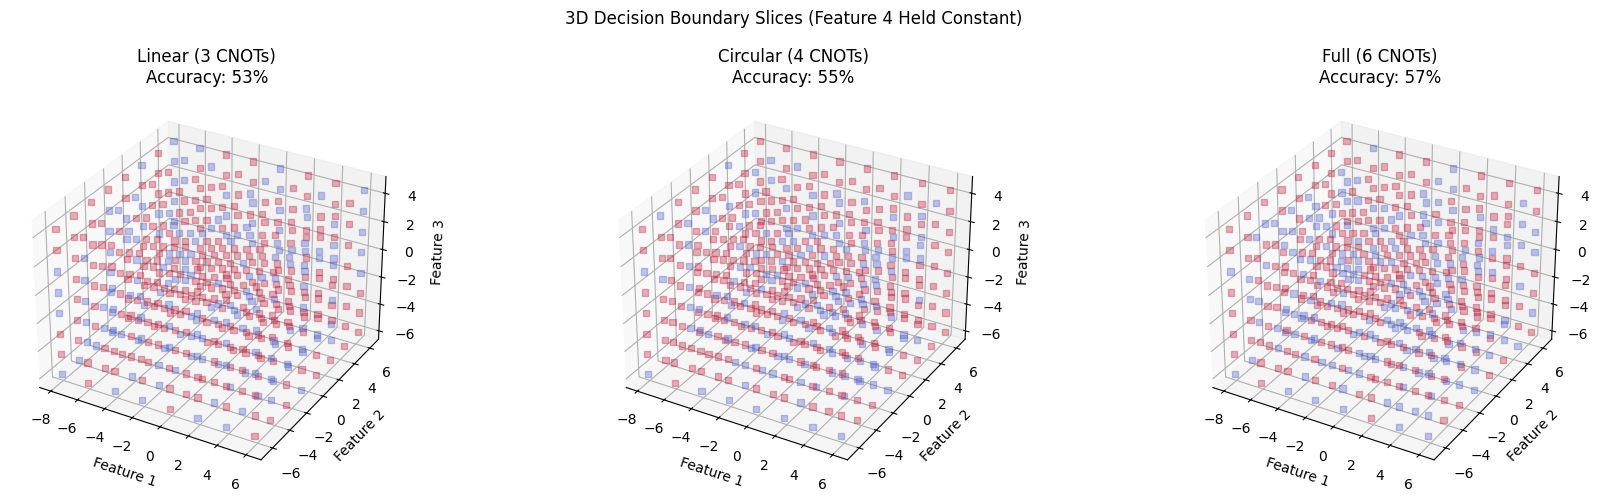

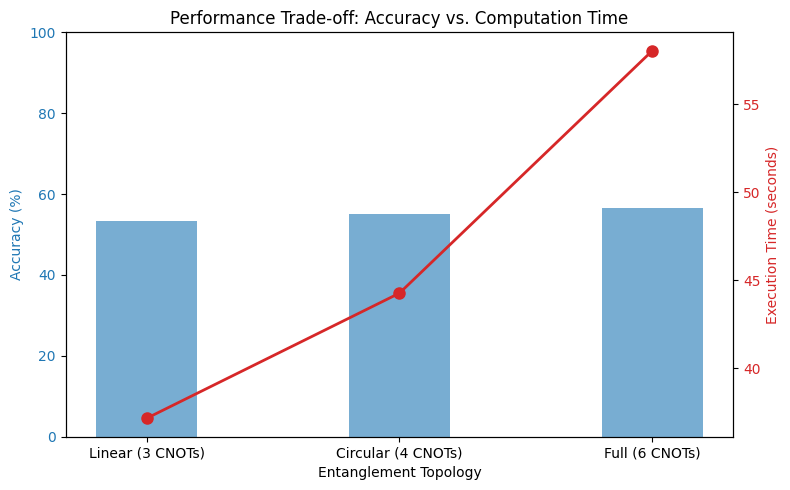

In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import time

In [ ]:
print("Generating noisy 4D dataset...")
X, y = make_classification(n_samples=200, n_features=4, n_informative=4,
                           n_redundant=0, class_sep=0.7, random_state=42)

y = np.where(y == 0, -1, 1)
X_scaled = X * (np.pi / 2)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
                c=X_scaled[:, 3], cmap='plasma', s=50, edgecolors='k')
plt.colorbar(sc, label="Feature 4 Value (Color)")
ax.set_title("4D Synthetic Dataset\n(Color indicates Feature 4)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.show()

In [ ]:
num_qubits = 4
dev = qml.device("default.qubit", wires=num_qubits)

def apply_zz(x_i, x_j, wire_i, wire_j):
    """Helper to apply the CNOT -> RZ -> CNOT interaction."""
    qml.CNOT(wires=[wire_i, wire_j])
    qml.RZ(x_i * x_j, wires=wire_j)
    qml.CNOT(wires=[wire_i, wire_j])

def fm_linear(x):
    qml.AngleEmbedding(x, wires=range(num_qubits))
    apply_zz(x[0], x[1], 0, 1)
    apply_zz(x[1], x[2], 1, 2)
    apply_zz(x[2], x[3], 2, 3)

def fm_circular(x):
    fm_linear(x)
    apply_zz(x[3], x[0], 3, 0)

def fm_full(x):
    qml.AngleEmbedding(x, wires=range(num_qubits))
    for i in range(num_qubits):
        for j in range(i + 1, num_qubits):
            apply_zz(x[i], x[j], i, j)

@qml.qnode(dev)
def kernel_linear(x1, x2):
    fm_linear(x1)
    qml.adjoint(fm_linear)(x2)
    return qml.probs(wires=range(num_qubits))

@qml.qnode(dev)
def kernel_circular(x1, x2):
    fm_circular(x1)
    qml.adjoint(fm_circular)(x2)
    return qml.probs(wires=range(num_qubits))

@qml.qnode(dev)
def kernel_full(x1, x2):
    fm_full(x1)
    qml.adjoint(fm_full)(x2)
    return qml.probs(wires=range(num_qubits))

def compute_matrix(A, B, qnode):
    matrix = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            matrix[i, j] = qnode(A[i], B[j])[0]
    return matrix

In [ ]:
topologies = {
    "Linear (3 CNOTs)": kernel_linear,
    "Circular (4 CNOTs)": kernel_circular,
    "Full (6 CNOTs)": kernel_full
}

results = {}
trained_svms = {}

for name, qnode in topologies.items():
    print(f"\n--- Training {name} ---")
    start_time = time.time()

    K_train = compute_matrix(X_train, X_train, qnode)

    svm = SVC(kernel='precomputed')
    svm.fit(K_train, y_train)
    trained_svms[name] = svm

    K_test = compute_matrix(X_test, X_train, qnode)
    acc = svm.score(K_test, y_test)

    elapsed = time.time() - start_time
    results[name] = {"accuracy": acc, "time": elapsed}
    print(f"Accuracy: {acc*100:.2f}% | Time: {elapsed:.2f} seconds")

In [ ]:
print("\nComputing boundary grids... (This will take a few minutes)")
grid_res = 8
f1 = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), grid_res)
f2 = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), grid_res)
f3 = np.linspace(X_scaled[:, 2].min(), X_scaled[:, 2].max(), grid_res)
xx, yy, zz = np.meshgrid(f1, f2, f3)

f4_mean = np.mean(X_scaled[:, 3])
f4_array = np.full_like(xx.ravel(), f4_mean)

grid_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel(), f4_array]

fig = plt.figure(figsize=(18, 5))

for idx, (name, qnode) in enumerate(topologies.items()):
    K_grid = compute_matrix(grid_points, X_train, qnode)
    Z = trained_svms[name].predict(K_grid)

    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    # Plot the grid points, colored by the SVM prediction
    sc = ax.scatter(xx.ravel(), yy.ravel(), zz.ravel(), c=Z,
                    cmap='coolwarm', alpha=0.3, marker='s')

    ax.set_title(f"{name}\nAccuracy: {results[name]['accuracy']*100:.0f}%")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Feature 3")

plt.suptitle("3D Decision Boundary Slices (Feature 4 Held Constant)")
plt.tight_layout()
plt.show()

In [ ]:
names = list(results.keys())
accuracies = [results[n]["accuracy"] * 100 for n in names]
times = [results[n]["time"] for n in names]

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Entanglement Topology')
ax1.set_ylabel('Accuracy (%)', color=color)
ax1.bar(names, accuracies, color=color, alpha=0.6, width=0.4, align='center')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Execution Time (seconds)', color=color)
# Shift the line plot slightly so it overlays nicely
ax2.plot(names, times, color=color, marker='o', linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Performance Trade-off: Accuracy vs. Computation Time")
fig.tight_layout()
plt.show()